In [23]:
import sys
sys.path.insert(0, "../../")

import json
import netket as nk
import jax
import jax.numpy as jnp
import prod.momentum_precond
import module.misc.tree_util as tree_util
import matplotlib.pyplot as plt

In [30]:
L = 10
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes)
ha = nk.operator.Ising(hilbert=hi, graph=g, h=1.0).to_jax_operator()
ma = nk.models.RBM(alpha=3, use_visible_bias=True, param_dtype=float)
sa = nk.sampler.MetropolisLocal(hi, n_chains=16)
op = nk.optimizer.Sgd(learning_rate=-1)
vs = nk.vqs.MCState(sa, ma, n_samples=1008, n_discard_per_chain=10)
E_f = nk.exact.lanczos_ed(ha, k = 1)[0]

In [31]:
initial_momentum = tree_util.t_zeros_like(vs.parameters)
preconditioner = prod.momentum_precond.SRMomentum(initial_momentum, 1e-2, 0.3)
gs = nk.VMC(ha, op, variational_state=vs, preconditioner=preconditioner)
gs.run(n_iter=100, out='prod/test_momentum')

  0%|          | 0/100 [00:00<?, ?it/s]

(JsonLog('prod/test_momentum', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.24509644508361816
   	Params: 0.24985694885253906,)

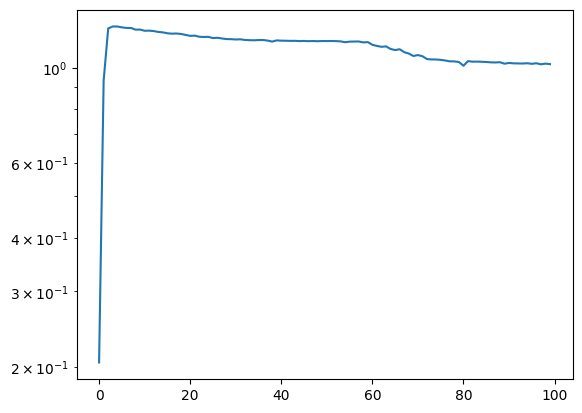

In [32]:
with open('prod/test_momentum.log', 'r') as file:
    # Read each line from the file
    for line in file:
        # Parse the JSON data from each line
        log_entry = json.loads(line)
        # Access the fields in the log entry
        energy = log_entry['Energy']['Mean']

plt.plot(jnp.abs(jnp.array(energy - E_f)/E_f))
plt.yscale("log")